In [2]:
from openai import OpenAI
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import silhouette_samples, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.colors as mcolors
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import pacmap
import random
random.seed(42)
import time

ds = load_dataset("TIGER-Lab/MMLU-Pro")

/Volumes/Crucial X9/knowledge-gaps/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Generating validation split: 100%|██████████| 70/70 [00:00<00:00, 29351.32 examples/s]


In [3]:
physics = ds['test'].filter(lambda x: x['category'] == 'physics')
print(physics)
print(len(physics))
print(np.unique(physics['question'] ))

Filter: 100%|██████████| 12032/12032 [00:00<00:00, 72152.02 examples/s]


Dataset({
    features: ['question_id', 'question', 'options', 'answer', 'answer_index', 'cot_content', 'category', 'src'],
    num_rows: 1299
})
1299
[' A British warship fires a projectile due south near the Falkland Islands during World War I at latitude $50^{\\circ} \\mathrm{S}$. If the shells are fired at $37^{\\circ}$ elevation with a speed of $800 \\mathrm{~m} / \\mathrm{s}$, by how much do the shells miss their target and in what direction? Ignore air resistance.'
 ' A charge of $20 \\mathrm{nC}$ is uniformly distributed along a straight rod of length $4.0 \\mathrm{~m}$ that is bent into a circular arc with a radius of $2.0 \\mathrm{~m}$. What is the magnitude of the electric field at the center of curvature of the arc?'
 ' An automobile with a mass of $1000 \\mathrm{~kg}$, including passengers, settles $1.0 \\mathrm{~cm}$ closer to the road for every additional $100 \\mathrm{~kg}$ of passengers. It is driven with a constant horizontal component of speed $20 \\mathrm{~km} / \\m

In [4]:
client = OpenAI()

# PHYSICS_CATEGORIES = [
#     "Mechanics", "Thermodynamics", "Electromagnetism",
#     "Optics", "Quantum Mechanics", "Nuclear Physics",
#     "Relativity", "Waves & Sound", "Fluid Dynamics"
# ]

# def categorize_question(question: str) -> str:
#     response = client.chat.completions.create(
#         model="gpt-4o-mini",
#         messages=[
#             {
#                 "role": "system",
#                 "content": (
#                     f"You are a physics expert. Classify the given physics question into exactly one of these categories: "
#                     f"{', '.join(PHYSICS_CATEGORIES)}. "
#                     f"Respond with only the category name, nothing else."
#                 )
#             },
#             {"role": "user", "content": question}
#         ],
#         temperature=0,
#         max_tokens=10,
#     )
#     label = response.choices[0].message.content.strip()
#     return label if label in PHYSICS_CATEGORIES else "Other"

texts = physics['question']

# # --- Categorize ---
# labels = []
# for i, q in enumerate(texts):
#     label = categorize_question(q)
#     labels.append(label)
#     if i % 50 == 0:
#         print(f"Categorized {i}/{len(texts)}: {label}")

# np.save("labels.npy", np.array(labels))  # save so you don't re-run

labels = np.load("labels.npy")

print(f"Categorization complete: {dict(zip(*np.unique(labels, return_counts=True)))}")

Categorization complete: {np.str_('Electromagnetism'): np.int64(197), np.str_('Fluid Dynamics'): np.int64(47), np.str_('Mechanics'): np.int64(382), np.str_('Nuclear Physics'): np.int64(89), np.str_('Optics'): np.int64(222), np.str_('Other'): np.int64(10), np.str_('Quantum Mechanics'): np.int64(74), np.str_('Relativity'): np.int64(53), np.str_('Thermodynamics'): np.int64(161), np.str_('Waves & Sound'): np.int64(64)}


In [5]:
# --- Embed ---
batch_size = 100
batches = [texts[i:i + batch_size] for i in range(0, len(texts), batch_size)]

result = []
for i, batch in enumerate(batches):
    response = client.embeddings.create(
        model="text-embedding-3-small",
        input=batch,
    )
    result.extend([np.array(item.embedding) for item in response.data])
    print(f"Processed batch {i+1}/{len(batches)} ({len(result)} embeddings so far)")
    time.sleep(0.5)

embeddings_matrix = np.array(result)
similarity_matrix = cosine_similarity(embeddings_matrix)

Processed batch 1/13 (100 embeddings so far)
Processed batch 2/13 (200 embeddings so far)
Processed batch 3/13 (300 embeddings so far)
Processed batch 4/13 (400 embeddings so far)
Processed batch 5/13 (500 embeddings so far)
Processed batch 6/13 (600 embeddings so far)
Processed batch 7/13 (700 embeddings so far)
Processed batch 8/13 (800 embeddings so far)
Processed batch 9/13 (900 embeddings so far)
Processed batch 10/13 (1000 embeddings so far)
Processed batch 11/13 (1100 embeddings so far)
Processed batch 12/13 (1200 embeddings so far)
Processed batch 13/13 (1299 embeddings so far)


### PaCMAP

In [6]:
np.shape(embeddings_matrix)

(1299, 1536)

In [7]:
print(labels)

['Mechanics' 'Nuclear Physics' 'Mechanics' ... 'Optics' 'Thermodynamics'
 'Thermodynamics']


Running ANNOY Indexing on high-dimensional data. Nearest-neighbor search may be slow!


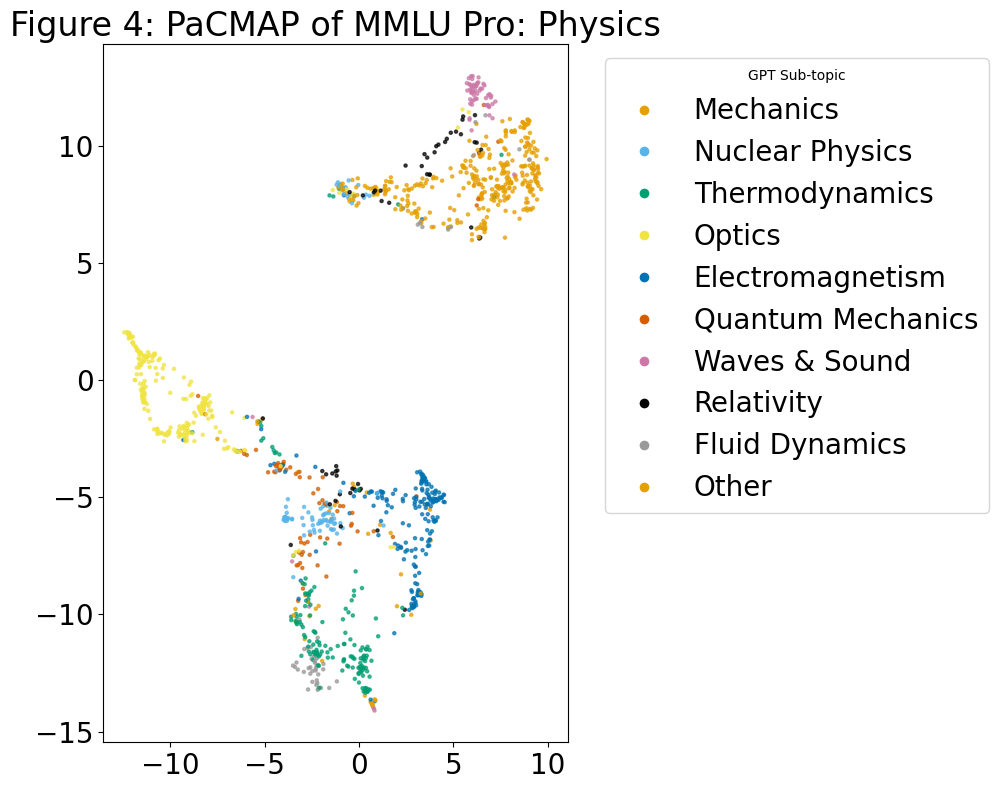

In [10]:
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pacmap

X = embeddings_matrix.astype(np.float32)
X = X / np.linalg.norm(X, axis=1, keepdims=True)

pca = PCA(n_components=50, random_state=42)
X_reduced = pca.fit_transform(X).astype(np.float32)

n_neighbors = 10
nn = NearestNeighbors(n_neighbors=n_neighbors + 1, metric='euclidean', n_jobs=-1)
nn.fit(X_reduced)
distances, indices = nn.kneighbors(X_reduced)

pair_neighbors = np.column_stack([
    np.repeat(np.arange(len(X_reduced)), n_neighbors),
    indices[:, 1:].ravel()
]).astype(np.int32)

embedding = pacmap.PaCMAP(
    n_components=2,
    n_neighbors=n_neighbors,
    MN_ratio=0.5,
    FP_ratio=2.0,
    apply_pca=False,
    random_state=42
)

embedding.pair_neighbors = pair_neighbors
X_transformed = embedding.fit_transform(X_reduced, init="pca")

OKABE_ITO = [
    "#E69F00", "#56B4E9", "#009E73", "#F0E442",
    "#0072B2", "#D55E00", "#CC79A7", "#000000", "#999999"
]

def plot_by_labels(ax, labels, title):
    unique_labels = list(dict.fromkeys(labels))
    color_map = {t: OKABE_ITO[i % len(OKABE_ITO)] for i, t in enumerate(unique_labels)}
    point_colors = [color_map[t] for t in labels]

    ax.scatter(X_transformed[:, 0], X_transformed[:, 1], c=point_colors, s=5, alpha=0.7)

    handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color_map[t],
                   markersize=8, label=t)
        for t in unique_labels
    ]
    ax.legend(handles=handles, title=title, bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=20)
    ax.tick_params(labelsize=20)
    ax.set_title(f"Figure 4: PaCMAP of MMLU Pro: Physics", fontsize=24)

# labels = your GPT-4o-mini categories, e.g. ["Mechanics", "Optics", ...]
# questions = the raw question text

fig, axes = plt.subplots(1, 1, figsize=(10, 8))
plot_by_labels(axes, labels, "GPT Sub-topic")

plt.tight_layout()
plt.show()

## How good are each cluster based on their type?

* mean_silhouette = how well-separated that topic type is from all others. Scores near +1 mean problems of this type cluster cleanly away from other types; scores near 0 or negative mean they bleed into neighboring topics in embedding space.

* intra_cosine_sim = how internally cohesive the cluster is. High values mean problems of this type are semantically similar to each other. You can have high intra-cosine but low silhouette if another cluster is just as cohesive and nearby.

* db_global = a single summary score for the whole partition. Lower is better; useful for comparing if you later experiment with different embedding models or dimensionality reduction settings.

https://www.geeksforgeeks.org/machine-learning/clustering-metrics/

In [14]:
from sklearn.metrics import silhouette_samples, davies_bouldin_score
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import numpy as np

def extract_first_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.split(" > ")[0].strip()

def extract_last_topic(x):
    if isinstance(x, list):
        x = x[0] if len(x) > 0 else "Unknown"
    x = str(x)
    return x.rsplit(" > ", 1)[-1].strip()

def compute_metrics(X, labels_text, label_name):
    unique_types = list(dict.fromkeys(labels_text))
    label_to_int = {t: i for i, t in enumerate(unique_types)}
    labels = np.array([label_to_int[t] for t in labels_text])

    sil_samples = silhouette_samples(X, labels, metric="cosine")
    db_global = davies_bouldin_score(X, labels)
    print(f"{label_name} Global Davies-Bouldin index: {db_global}")

    rows = []
    for t in unique_types:
        mask = np.array(labels_text) == t
        cluster_embeddings = X[mask]

        mean_sil = sil_samples[mask].mean()

        if len(cluster_embeddings) > 1:
            sim_matrix = cosine_similarity(cluster_embeddings)
            n = len(cluster_embeddings)
            upper_tri = sim_matrix[np.triu_indices(n, k=1)]
            intra_cosine = upper_tri.mean()
        else:
            intra_cosine = float("nan")

        rows.append({
            "topic_type": t,
            "n_samples": int(mask.sum()),
            "mean_silhouette": round(float(mean_sil), 4),
            "intra_cosine_sim": round(float(intra_cosine), 4),
        })

    df_metrics = pd.DataFrame(rows).sort_values("mean_silhouette", ascending=False)
    print(f"\n{label_name} metrics:")
    print(df_metrics.to_string(index=False))
    return df_metrics, db_global

df_metrics_first, db_first = compute_metrics(X, labels, "First topic")

First topic Global Davies-Bouldin index: 4.325541759559454

First topic metrics:
       topic_type  n_samples  mean_silhouette  intra_cosine_sim
           Optics        222           0.1351            0.3443
    Waves & Sound         64           0.1115            0.3330
 Electromagnetism        197           0.0841            0.3246
Quantum Mechanics         74           0.0752            0.3410
   Fluid Dynamics         47           0.0549            0.2854
   Thermodynamics        161           0.0440            0.2963
       Relativity         53           0.0391            0.3025
  Nuclear Physics         89           0.0250            0.2837
            Other         10           0.0085            0.2666
        Mechanics        382           0.0006            0.2528
